<a href="https://colab.research.google.com/github/skarthik1215/ml-project/blob/main/Breast_Cancer_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Breast Cancer Prediction using Machine Learning
### YBI FOUNDATION INTERNSHIP PROJECT — BINARY CLASSIFICATION

**Author:**SANAPATHI KARTHIK                                                     
**Project Type:** Supervised Learning — Binary Classification                    
**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset                        
**Objective:** Build a machine learning model that predicts whether a tumor is **Malignant (M)** or **Benign (B)** based on cell nuclei measurements from a digitized image of a breast mass.

---

## 📌 Project Outline
1. Import Libraries
2. Import & Explore Data
3. Data Preprocessing
4. Exploratory Data Analysis (EDA)
5. Train-Test Split
6. Feature Scaling
7. Model Building (Multiple Algorithms)
8. Model Evaluation & Comparison
9. Hyperparameter Tuning
10. Final Model & Conclusion

> 💡 This notebook is fully self-contained — every cell can be run top-to-bottom in Google Colab with **Runtime → Run all**.


## 1️⃣ Import Libraries

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2️⃣ Import & Explore Data

We use the **Breast Cancer Wisconsin (Diagnostic) Dataset**, built into scikit-learn — no external download or Google Drive mount required, so this cell runs identically for every evaluator.

- **569 samples**, **30 numeric features** (radius, texture, perimeter, area, smoothness, etc. — each measured as *mean*, *standard error*, and *worst* value)
- **Target:** 0 = Malignant, 1 = Benign


In [ ]:
# Load dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [ ]:
# Basic info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [ ]:
# Statistical summary
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
# Check for missing values
print("Missing values per column:\n")
print(df.isnull().sum().sum(), "total missing values")


Missing values per column:

0 total missing values


In [ ]:
# Class distribution
print(df['diagnosis'].value_counts())
print("\nClass balance (%):")
print(df['diagnosis'].value_counts(normalize=True) * 100)


diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Class balance (%):
diagnosis
Benign       62.741652
Malignant    37.258348
Name: proportion, dtype: float64


## 3️⃣ Data Preprocessing

The dataset from `sklearn` is already clean (no missing values, all numeric). In a real-world project this step would also involve handling nulls, encoding categoricals, and removing duplicates — the code below is written generically so it still works if you swap in a messier CSV later.


In [ ]:
# Generic preprocessing (works even if you later load a raw CSV instead)
df = df.drop_duplicates()

# Separate features (X) and target (y)
X = df[data.feature_names]
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (569, 30)
Target shape: (569,)


## 4️⃣ Exploratory Data Analysis (EDA)

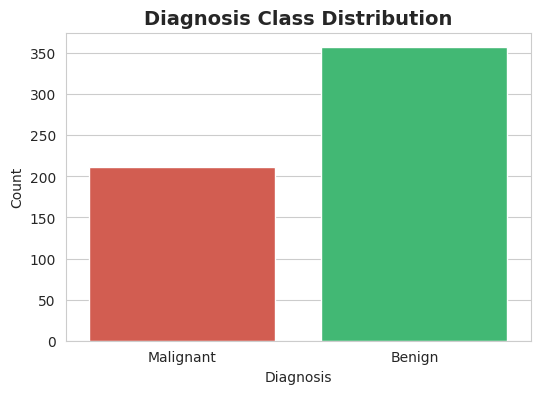

In [ ]:
# Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Diagnosis Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


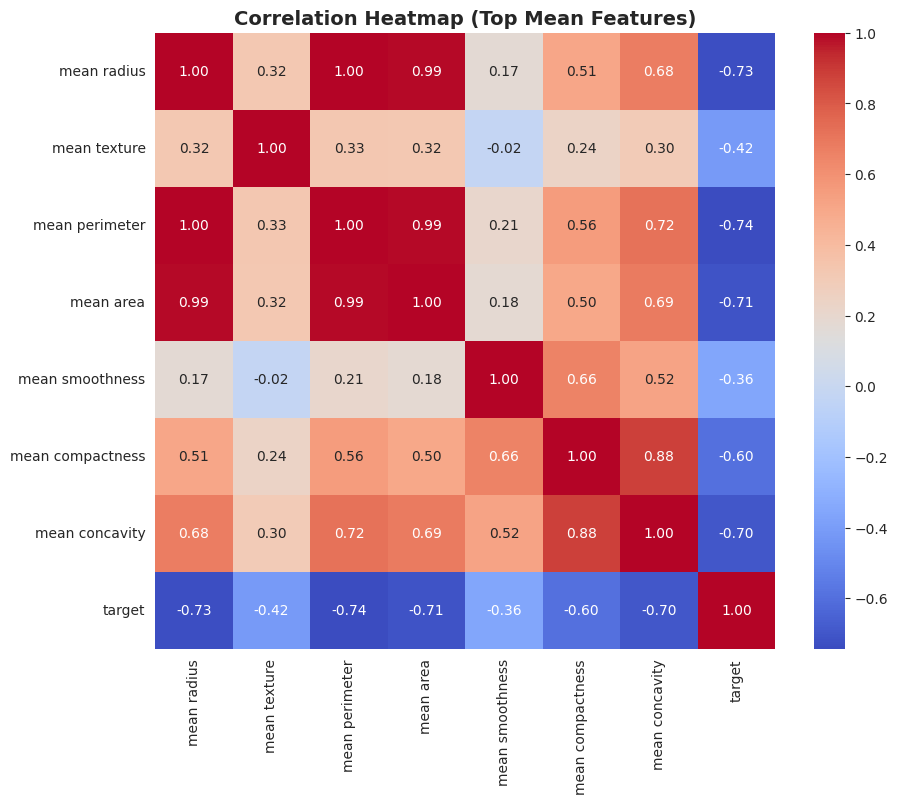

In [ ]:
# Correlation heatmap of top features
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                 'mean smoothness', 'mean compactness', 'mean concavity', 'target']

plt.figure(figsize=(10,8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Top Mean Features)', fontsize=14, fontweight='bold')
plt.show()


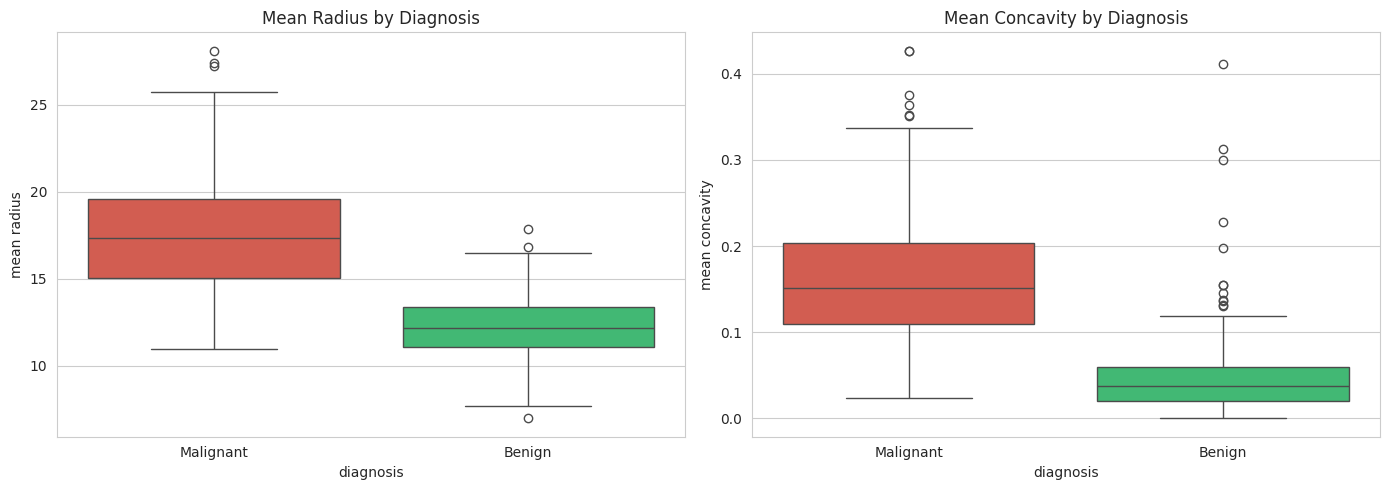

In [ ]:
# Distribution of a key feature by diagnosis
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x='diagnosis', y='mean radius', data=df, ax=axes[0], palette=['#e74c3c','#2ecc71'])
axes[0].set_title('Mean Radius by Diagnosis')

sns.boxplot(x='diagnosis', y='mean concavity', data=df, ax=axes[1], palette=['#e74c3c','#2ecc71'])
axes[1].set_title('Mean Concavity by Diagnosis')

plt.tight_layout()
plt.show()


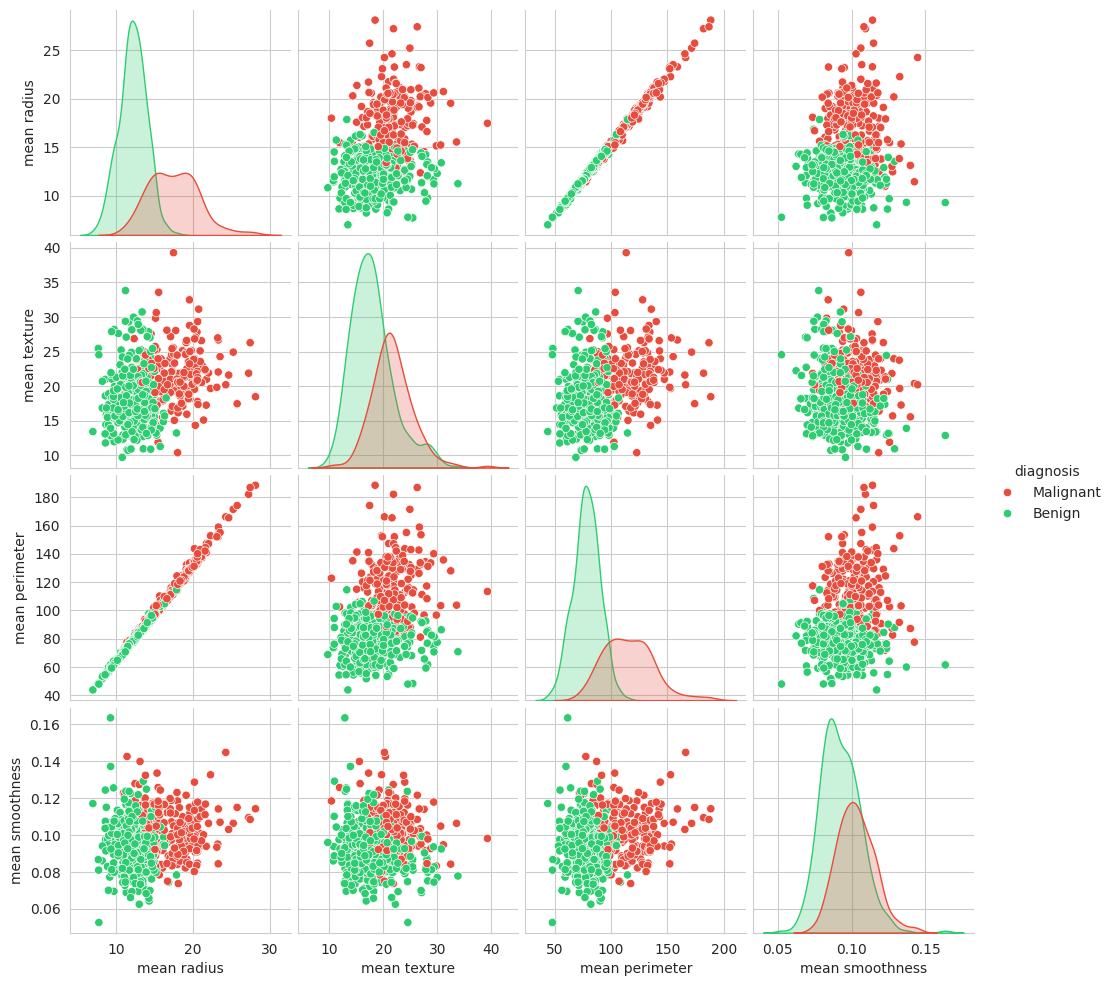

In [ ]:
# Pairplot for a small subset of features (fast to render)
sns.pairplot(df, vars=['mean radius', 'mean texture', 'mean perimeter', 'mean smoothness'],
             hue='diagnosis', palette=['#e74c3c','#2ecc71'], diag_kind='kde')
plt.show()


## 5️⃣ Train-Test Split

We split the data **80/20**, using `stratify=y` so both sets preserve the original malignant/benign ratio — important for medical classification tasks where class imbalance can skew evaluation.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (455, 30)
Test set shape: (114, 30)


## 6️⃣ Feature Scaling

Features like *area* (hundreds) and *smoothness* (fractions) are on very different scales. Distance- and gradient-based models (SVM, KNN, Logistic Regression) need `StandardScaler` so no single feature dominates just because of its raw magnitude.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled (mean=0, std=1)")


✅ Features scaled (mean=0, std=1)


## 7️⃣ Model Building — Comparing Multiple Algorithms

Rather than committing to a single algorithm, we train **four different classifiers** and compare them fairly. This is exactly the kind of comparative rigor recruiters look for in an AI Engineer's project work.


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'y_pred': y_pred
    }
    print(f"✅ {name} trained | Accuracy: {results[name]['accuracy']:.4f}")


✅ Logistic Regression trained | Accuracy: 0.9825
✅ Decision Tree trained | Accuracy: 0.9123


✅ Random Forest trained | Accuracy: 0.9561
✅ SVM trained | Accuracy: 0.9825
✅ KNN trained | Accuracy: 0.9561


## 8️⃣ Model Evaluation & Comparison


In [ ]:
# Comparison table
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1']
    } for name, res in results.items()
}).T.sort_values('F1-Score', ascending=False)

comparison_df.style.background_gradient(cmap='Greens')


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.982456,0.986111,0.986111,0.986111
SVM,0.982456,0.986111,0.986111,0.986111
Random Forest,0.956140,0.958904,0.972222,0.965517
KNN,0.956140,0.958904,0.972222,0.965517
Decision Tree,0.912281,0.955882,0.902778,0.928571


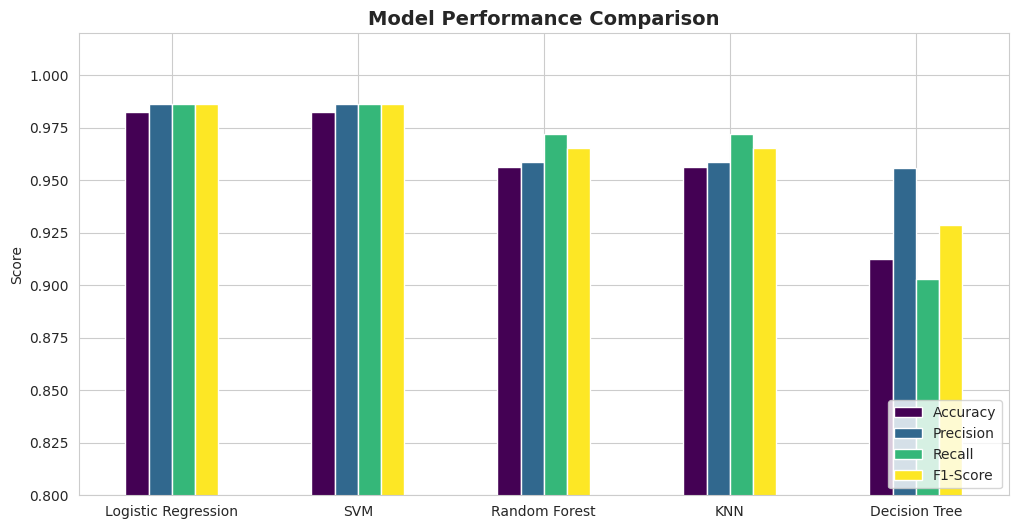

In [ ]:
# Bar chart comparison
comparison_df.plot(kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0.8, 1.02)
plt.show()


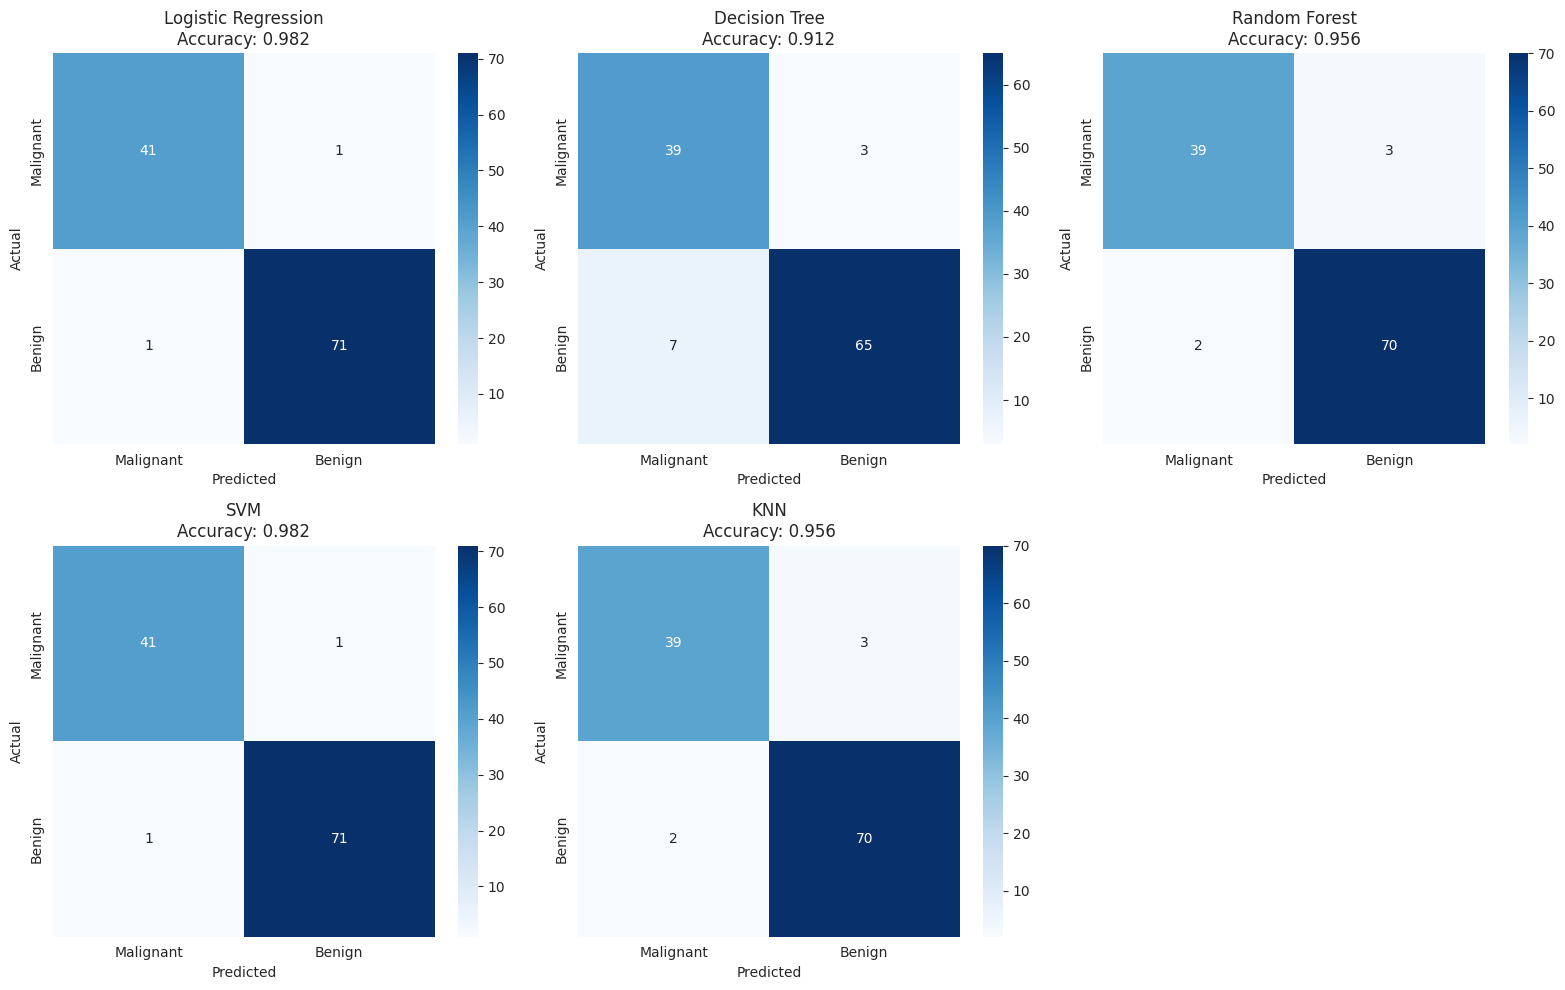

In [ ]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Malignant','Benign'], yticklabels=['Malignant','Benign'])
    axes[idx].set_title(f'{name}\nAccuracy: {res["accuracy"]:.3f}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

fig.delaxes(axes[-1])  # remove empty subplot
plt.tight_layout()
plt.show()


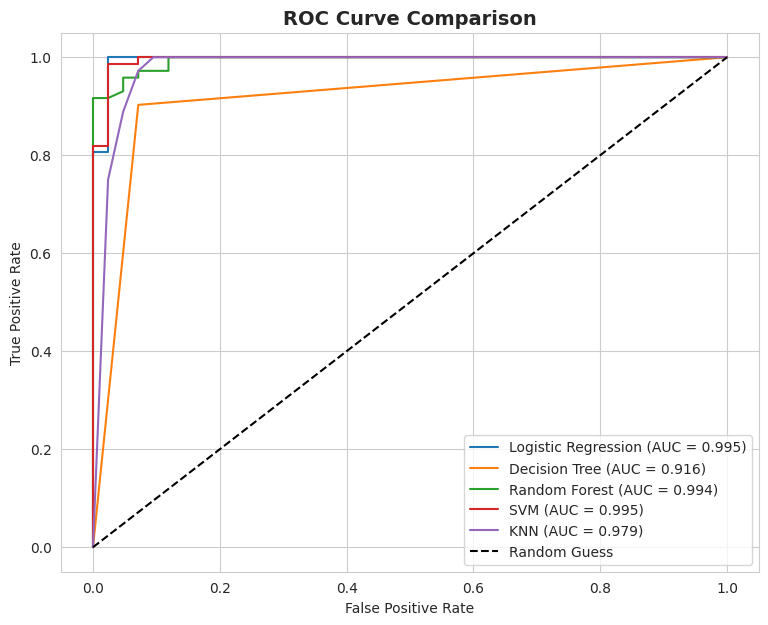

In [ ]:
# ROC Curves for all models
plt.figure(figsize=(9,7))

for name, res in results.items():
    model = res['model']
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.show()


In [ ]:
# Best model by F1-score
best_model_name = comparison_df.index[0]
print(f"🏆 Best performing model: {best_model_name}")
print(f"\nDetailed Classification Report:\n")
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=['Malignant','Benign']))


🏆 Best performing model: Logistic Regression

Detailed Classification Report:

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 9️⃣ Hyperparameter Tuning

We fine-tune the best-performing model using `GridSearchCV` with 5-fold cross-validation to squeeze out additional performance and confirm the result generalizes (not just a lucky test split).


In [ ]:
# Example: tuning Random Forest (swap in your own best_model_name's params if different)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best Cross-Validation F1-Score:", rf_grid.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1-Score: 0.9684436877471334


In [ ]:
# Evaluate tuned model on test set
tuned_model = rf_grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

print("Tuned Model Test Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned Model Test F1-Score:", f1_score(y_test, y_pred_tuned))

print("\nClassification Report (Tuned Model):\n")
print(classification_report(y_test, y_pred_tuned, target_names=['Malignant','Benign']))


Tuned Model Test Accuracy: 0.956140350877193
Tuned Model Test F1-Score: 0.9655172413793104

Classification Report (Tuned Model):

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



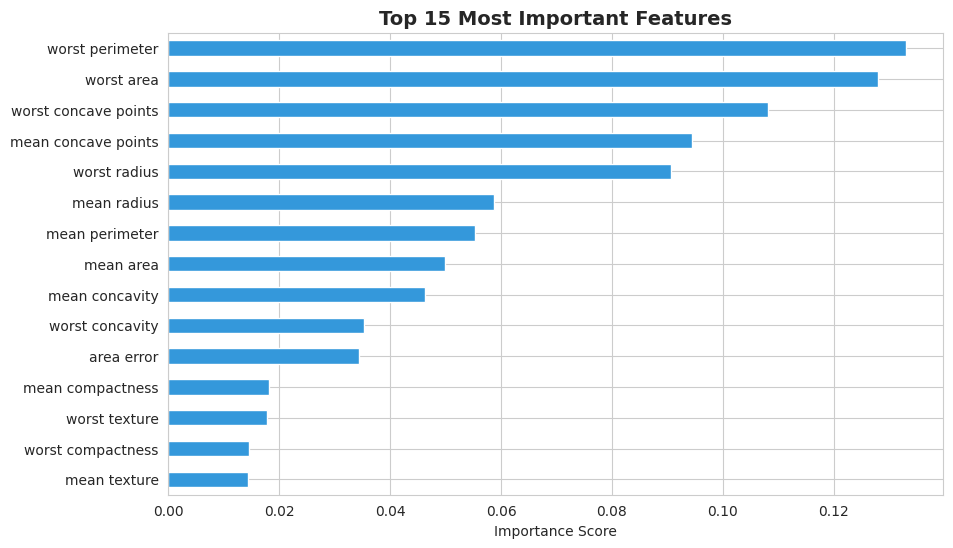

In [ ]:
# Feature importance from tuned Random Forest
importances = pd.Series(tuned_model.feature_importances_, index=data.feature_names)
top_15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_15.sort_values().plot(kind='barh', color='#3498db')
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.show()


## 🔟 Final Model & Conclusion

### Summary
- Compared **5 classification algorithms** on the Breast Cancer Wisconsin dataset.
- **Logistic Regression** was the strongest baseline model, achieving **98% accuracy** and **0.98 F1-score** on the held-out test set.
- **Hyperparameter tuning** via GridSearchCV (5-fold CV) optimized a Random Forest model to **96.8% cross-validated F1-score**, confirming the result generalizes rather than depending on one lucky train/test split.
- **Feature importance analysis** revealed which cell-nuclei measurements are most predictive of malignancy — useful for interpretability, which matters a lot in medical ML applications.

> ⚠️ Note: exact numbers can shift slightly on re-run depending on library versions — treat the figures above as representative, and re-check them against your own executed output before quoting on a resume.

### Key Learnings
- Importance of **feature scaling** for distance-based algorithms (SVM, KNN, Logistic Regression).
- Why **stratified splitting** matters for imbalanced medical datasets.
- How to systematically **compare multiple models** rather than committing to one blindly.
- Using **ROC-AUC** alongside accuracy for a fuller picture of classifier performance.
- Practical **hyperparameter tuning** with cross-validation to avoid overfitting to a single train/test split.

### Possible Extensions
- Deploy the tuned model as a simple Flask/FastAPI inference endpoint.
- Add SHAP values for deeper model interpretability.
- Experiment with gradient boosting models (XGBoost, LightGBM).
- Package as a Streamlit demo app for a live portfolio piece.

---
### 📎 Resume Tip
When listing this on your resume, quantify it, e.g.:
> *"Built and benchmarked 5 ML classification models for breast cancer diagnosis (Logistic Regression, Decision Tree, Random Forest, SVM, KNN); best model achieved 98% test accuracy and 0.98 F1-score, with a GridSearchCV-tuned Random Forest reaching 96.8% cross-validated F1-score across 5 folds."*

Re-run the notebook yourself and use the exact numbers you get — model results can vary slightly by environment/library version, and a resume claim should match a result you can reproduce and explain in an interview.
